In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
x,y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)


In [3]:
df = pd.DataFrame(x, columns=['feature1', 'feature2'])
df.head()

,feature1,feature2
0,0.836857,2.136359
1,-1.413658,7.409623
2,1.155213,5.099619
3,-1.018616,7.814915
4,1.271351,1.892542


In [4]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [7]:
inertia=[]
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

In [8]:
inertia

[600.0000000000001,
 270.3431137506444,
 139.34634510769777,
 56.024770575099495,
 48.60211490891996,
 41.797146136796435,
 35.22161787598454,
 29.452441405736927,
 27.417236930918214,
 25.2317972775124]

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

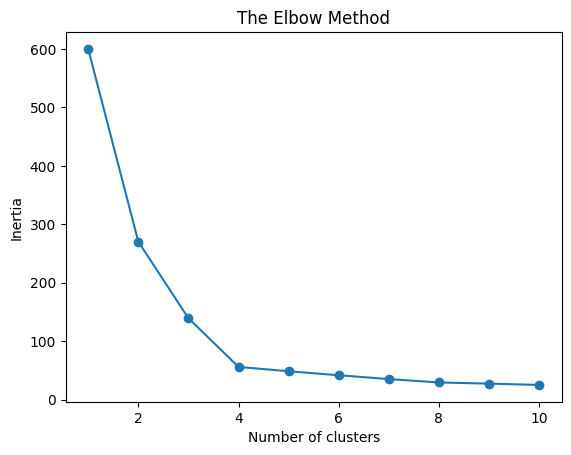

In [9]:
plt.plot(range(1,11), inertia, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt

In [ ]:
#from the above diagram (elbow method) we can say that the best k value is 4

In [10]:
kmeans_final=KMeans(n_clusters=3, random_state=42)

In [11]:
cluster_labels = kmeans_final.fit_predict(x_scaled)

In [12]:
df['cluster']=cluster_labels

In [13]:
cluster_labels

array([0, 1, 2, 1, 0, 0, 1, 2, 1, 1, 1, 1, 2, 1, 0, 2, 2, 0, 1, 1, 0, 0,
       2, 1, 1, 1, 0, 2, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 0, 2, 1, 2, 2,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 2, 1, 1, 1, 1,
       1, 0, 1, 1, 2, 2, 1, 1, 1, 1, 1, 2, 0, 1, 0, 2, 0, 0, 1, 2, 0, 2,
       1, 1, 2, 0, 1, 1, 1, 2, 0, 0, 2, 1, 1, 0, 1, 0, 2, 0, 0, 2, 1, 2,
       1, 1, 0, 1, 0, 2, 1, 0, 0, 2, 2, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1, 2,
       0, 1, 1, 1, 0, 2, 1, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2, 1, 0, 2, 1, 1,
       0, 0, 2, 1, 0, 2, 1, 1, 2, 2, 2, 2, 0, 1, 2, 1, 2, 2, 1, 1, 1, 2,
       1, 1, 2, 1, 0, 1, 2, 1, 1, 1, 2, 1, 2, 1, 2, 2, 1, 1, 1, 0, 0, 2,
       1, 0, 0, 1, 0, 1, 2, 1, 1, 2, 2, 1, 2, 0, 1, 2, 0, 1, 1, 1, 0, 2,
       0, 1, 1, 1, 1, 1, 1, 1, 2, 1, 0, 2, 1, 1, 1, 0, 0, 1, 2, 2, 1, 0,
       1, 1, 2, 1, 2, 0, 0, 1, 1, 2, 0, 0, 0, 2, 1, 1, 0, 0, 2, 0, 0, 0,
       1, 1, 1, 2, 0, 0, 1, 1, 1, 0, 0, 2, 2, 1], d

<Axes: xlabel='feature1', ylabel='feature2'>

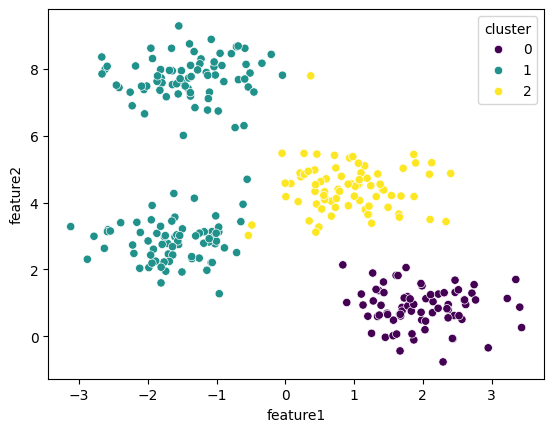

In [16]:
sns.scatterplot(
    x=df['feature1'],
    y=df['feature2'],
    hue=df['cluster'],
    palette='viridis'
)